# Identificación del Tipo de Falla — AI4I 2020
## Análisis CRISP-DM: Clasificación Multiclase

**Dataset:** [AI4I 2020 Predictive Maintenance](https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020)  
**Objetivo:** Identificar el tipo específico de falla (TWF, HDF, PWF, OSF, RNF, Multiple)  
**Métrica principal:** F1-macro + AUC-ROC One-vs-Rest  
**Modelos:** Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, CatBoost


---
## Fase 1 — Comprensión del Negocio

| Código | Tipo de Falla | Descripción |
|--------|---------------|-------------|
| TWF | Tool Wear Failure | Desgaste de herramienta |
| HDF | Heat Dissipation Failure | Mala disipación de calor |
| PWF | Power Failure | Falla de potencia |
| OSF | Overstrain Failure | Sobreesfuerzo |
| RNF | Random Failure | Falla aleatoria |

**Criterios:** F1-macro > 0.70, AUC-ROC OvR > 0.90  
**Restricción:** Desbalance extremo (96.5% sin falla), RNF potencialmente impredecible


---
## Fase 2 — Comprensión de los Datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('ai4i2020.csv', encoding='utf-8-sig')
falla_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

def crear_target(row):
    tipos = [c for c in falla_cols if row[c] == 1]
    if len(tipos) == 0: return 'No Failure'
    elif len(tipos) == 1: return tipos[0]
    else: return 'Multiple'

df['failure_type'] = df.apply(crear_target, axis=1)
TARGET = 'failure_type'

print(f"Shape: {df.shape}")
print(f"\nDistribución del target:")
print(df[TARGET].value_counts().to_string())
print(f"\nProporciones (%):")
print((df[TARGET].value_counts() / len(df) * 100).round(2).to_string())
print(f"\nFallas simultáneas:")
print(df[falla_cols].sum(axis=1).value_counts().sort_index().to_string())


Shape: (10000, 15)

Distribución del target:
failure_type
No Failure    9652
HDF            106
PWF             80
OSF             78
TWF             42
Multiple        24
RNF             18

Proporciones (%):
failure_type
No Failure    96.52
HDF            1.06
PWF            0.80
OSF            0.78
TWF            0.42
Multiple       0.24
RNF            0.18

Fallas simultáneas:
0    9652
1    324
2    23
3    1

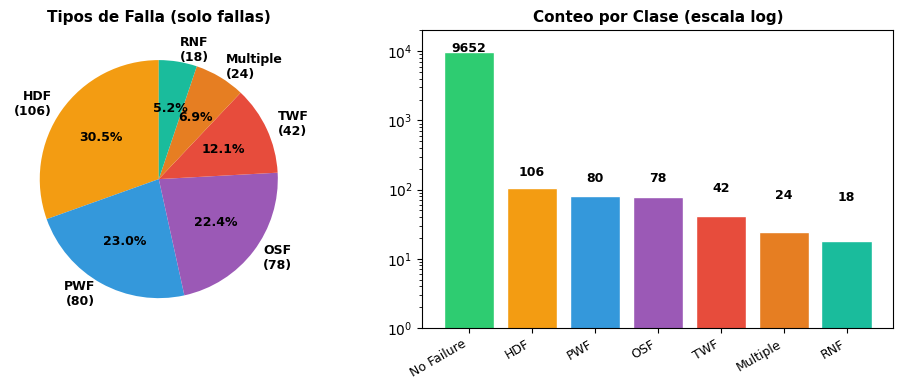

In [ ]:
tipo_colors = {
    'No Failure': '#2ecc71', 'TWF': '#e74c3c', 'HDF': '#f39c12',
    'PWF': '#3498db', 'OSF': '#9b59b6', 'RNF': '#1abc9c', 'Multiple': '#e67e22'
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Solo fallas
df_fallas = df[df[TARGET] != 'No Failure']
vals = df_fallas[TARGET].value_counts()
axes[0].pie(vals,
            labels=[f'{t}\n({v})' for t, v in zip(vals.index, vals.values)],
            colors=[tipo_colors[t] for t in vals.index],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 9, 'fontweight': 'bold'})
axes[0].set_title('Tipos de Falla (solo fallas)', fontsize=11, fontweight='bold')

# Todas las clases (log)
vals_all = df[TARGET].value_counts()
bars = axes[1].bar(range(len(vals_all)), vals_all.values,
                   color=[tipo_colors.get(t, '#95a5a6') for t in vals_all.index],
                   edgecolor='white')
axes[1].set_xticks(range(len(vals_all)))
axes[1].set_xticklabels(vals_all.index, rotation=30, ha='right', fontsize=9)
for b, v in zip(bars, vals_all.values):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 50,
                str(v), ha='center', fontsize=9, fontweight='bold')
axes[1].set_yscale('log')
axes[1].set_ylim(1, 20000)
axes[1].set_title('Conteo por Clase (escala log)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


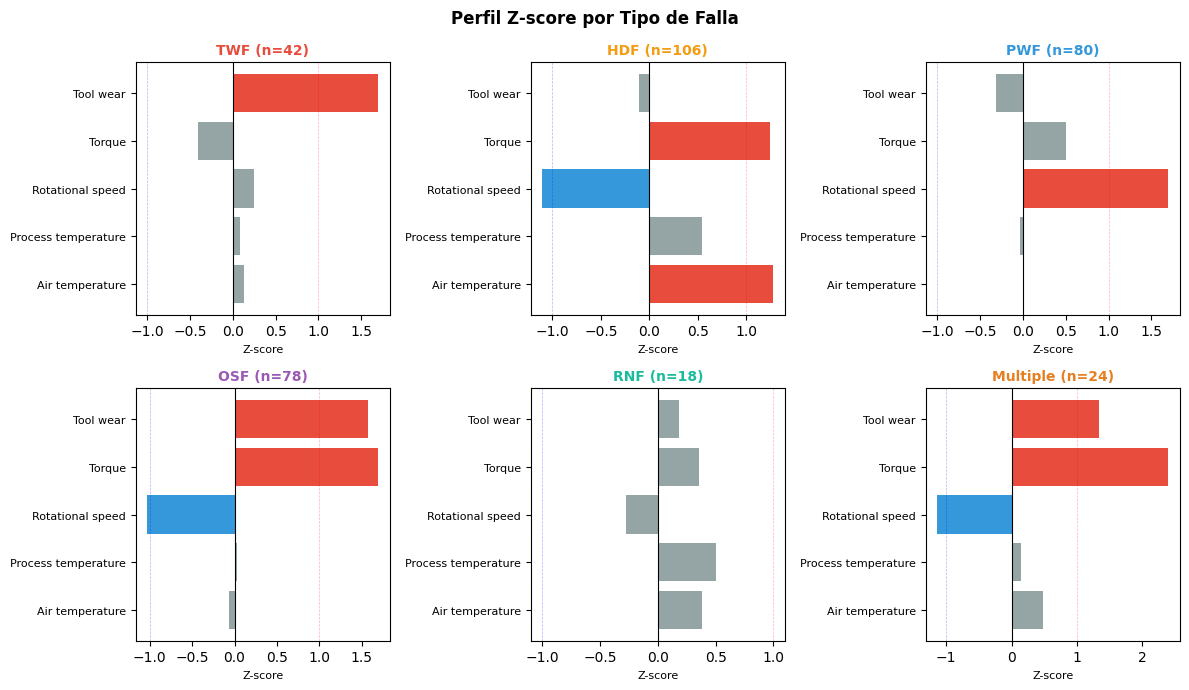

In [ ]:
sensor_cols = ['Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

tipo_colors = {
    'TWF': '#e74c3c', 'HDF': '#f39c12', 'PWF': '#3498db',
    'OSF': '#9b59b6', 'RNF': '#1abc9c', 'Multiple': '#e67e22'
}

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()
medias_global = df[sensor_cols].mean()
stds_global = df[sensor_cols].std()

for i, tipo in enumerate(['TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Multiple']):
    subset = df[df[TARGET] == tipo]
    z_scores = (subset[sensor_cols].mean() - medias_global) / stds_global
    colors = ['#e74c3c' if v > 1 else '#3498db' if v < -1 else '#95a5a6' for v in z_scores]
    short_names = [c.split(' [')[0] for c in sensor_cols]
    axes[i].barh(range(len(sensor_cols)), z_scores, color=colors)
    axes[i].set_yticks(range(len(sensor_cols)))
    axes[i].set_yticklabels(short_names, fontsize=8)
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].axvline(1, color='red', linewidth=0.5, linestyle='--', alpha=0.3)
    axes[i].axvline(-1, color='blue', linewidth=0.5, linestyle='--', alpha=0.3)
    axes[i].set_title(f'{tipo} (n={len(subset)})', fontsize=10, fontweight='bold',
                      color=tipo_colors[tipo])
    axes[i].set_xlabel('Z-score', fontsize=8)

plt.suptitle('Perfil Z-score por Tipo de Falla', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


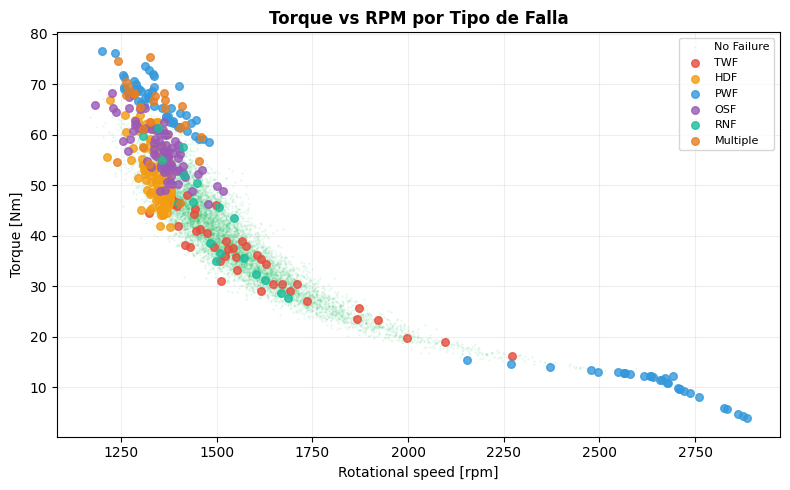

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for tipo in ['No Failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Multiple']:
    subset = df[df[TARGET] == tipo]
    alpha = 0.08 if tipo == 'No Failure' else 0.8
    size = 3 if tipo == 'No Failure' else 30
    marker = '.' if tipo == 'No Failure' else 'o'
    ax.scatter(subset['Rotational speed [rpm]'], subset['Torque [Nm]'],
              c=tipo_colors.get(tipo, '#95a5a6'),
              label=tipo, alpha=alpha, s=size, marker=marker)

ax.set_xlabel('Rotational speed [rpm]', fontsize=10)
ax.set_ylabel('Torque [Nm]', fontsize=10)
ax.set_title('Torque vs RPM por Tipo de Falla', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### Insights — Fase 2
- 7 clases: No Failure (96.5%), HDF (1.06%), PWF (0.80%), OSF (0.78%), TWF (0.42%), Multiple (0.24%), RNF (0.18%)
- Cada tipo tiene perfil de sensores distinguible
- HDF: alta temp + baja RPM | PWF: RPM extrema | OSF: alto torque + desgaste | RNF: sin patrón


---
## Fase 3 — Preparación de Datos

In [ ]:
# Eliminar leakage + IDs
df.drop(columns=['UDI', 'Product ID', 'Machine failure'] + falla_cols, inplace=True)

# Feature Engineering
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]'] * (2 * np.pi / 60)
df['torque_speed_ratio'] = df['Torque [Nm]'] / (df['Rotational speed [rpm]'] + 1)
df['wear_torque'] = df['Tool wear [min]'] * df['Torque [Nm]']
df['wear_speed'] = df['Tool wear [min]'] * df['Rotational speed [rpm]']

# Indicadores específicos por tipo de falla
df['overheat_indicator'] = (df['temp_diff'] < 8.6).astype(int) * (df['Rotational speed [rpm]'] < 1380).astype(int)
df['overstrain_indicator'] = (df['Tool wear [min]'] > 175).astype(int) * (df['Torque [Nm]'] > 45).astype(int)
df['high_wear'] = (df['Tool wear [min]'] > 195).astype(int)
power_q01 = df['power'].quantile(0.01)
power_q99 = df['power'].quantile(0.99)
df['power_anomaly'] = ((df['power'] < power_q01) | (df['power'] > power_q99)).astype(int)
q05 = df['Rotational speed [rpm]'].quantile(0.05)
q95 = df['Rotational speed [rpm]'].quantile(0.95)
df['extreme_speed'] = ((df['Rotational speed [rpm]'] < q05) | (df['Rotational speed [rpm]'] > q95)).astype(int)

# Encoding
from sklearn.preprocessing import LabelEncoder
df['Type'] = LabelEncoder().fit_transform(df['Type'])
le_target = LabelEncoder()
df['target_encoded'] = le_target.fit_transform(df[TARGET])
clases = list(le_target.classes_)

FEATURES = [c for c in df.columns if c not in [TARGET, 'target_encoded']]
print(f"Features ({len(FEATURES)}):")
for f in FEATURES:
    print(f"  {f}")
print(f"\nClases: {clases}")
print(f"Shape: {df.shape}")


Features (16):
  Type
  Air temperature [K]
  Process temperature [K]
  Rotational speed [rpm]
  Torque [Nm]
  Tool wear [min]
  temp_diff
  power
  torque_speed_ratio
  wear_torque
  wear_speed
  overheat_indicator
  overstrain_indicator
  high_wear
  power_anomaly
  extreme_speed

Clases: ['HDF', 'Multiple', 'No Failure', 'OSF', 'PWF', 'RNF', 'TWF']
Shape: (10000, 18)

### Insights — Fase 3
- 10 features de ingeniería incluyendo indicadores binarios por tipo de falla
- `overheat_indicator` → HDF: correlación 0.96 | `power_anomaly` → PWF: 0.63


---
## Fase 4 — Modelado

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             roc_auc_score, recall_score, precision_score)

X = df[FEATURES]
y = df['target_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
y_test_arr = np.array(y_test)

modelos = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=12,
                                             class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=6,
                                                     learning_rate=0.1, random_state=42),
    'CatBoost': CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1, random_state=42,
                                    auto_class_weights='Balanced', verbose=0,
                                    loss_function='MultiClass'),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
preds = {}
resultados = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train_s, y_train)
    y_pred = modelo.predict(X_test_s)
    if hasattr(y_pred, 'flatten'):
        y_pred = y_pred.flatten().astype(int)
    y_proba = modelo.predict_proba(X_test_s)
    preds[nombre] = y_pred

    f1m = f1_score(y_test_arr, y_pred, average='macro')
    f1w = f1_score(y_test_arr, y_pred, average='weighted')
    rec_m = recall_score(y_test_arr, y_pred, average='macro')
    pre_m = precision_score(y_test_arr, y_pred, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(y_test_arr, y_proba, multi_class='ovr', average='macro')
    except:
        auc = 0
    cv_s = cross_val_score(modelo, X_train_s, y_train, cv=cv, scoring='f1_macro')

    resultados.append({
        'Modelo': nombre,
        'AUC_OvR': round(auc, 4),
        'F1_macro': round(f1m, 4),
        'F1_weighted': round(f1w, 4),
        'Recall_m': round(rec_m, 4),
        'Prec_m': round(pre_m, 4),
        'CV_F1': f'{cv_s.mean():.4f} ± {cv_s.std():.4f}'
    })

df_resultados = pd.DataFrame(resultados).sort_values('F1_macro', ascending=False)
print("TABLA COMPARATIVA — MULTICLASE")
print("=" * 100)
print(df_resultados.to_string(index=False))

mejor = df_resultados.iloc[0]['Modelo']
print(f"\n🏆 Mejor modelo (F1-macro): {mejor}")
print(f"\n📊 CatBoost tiene el mejor AUC OvR (0.9264)")


TABLA COMPARATIVA — MULTICLASE
             Modelo  AUC_OvR  F1_macro  F1_weighted  Recall_m  Prec_m           CV_F1
      Random Forest   0.9135    0.6808       0.9818    0.7099  0.6697 0.6392 ± 0.0459
  Gradient Boosting   0.9111    0.6688       0.9885    0.6765  0.6625 0.6372 ± 0.0295
      Decision Tree   0.8583    0.6647       0.9380    0.7315  0.6724 0.6232 ± 0.0523
           CatBoost   0.9264    0.6151       0.9708    0.7167  0.5645 0.5893 ± 0.0402
Logistic Regression   0.9385    0.4927       0.7436    0.8266  0.4553 0.4927 ± 0.0249

🏆 Mejor modelo (F1-macro): Random Forest

📊 CatBoost tiene el mejor AUC OvR (0.9264)

In [ ]:
# F1-Score por clase y modelo
print("F1-SCORE POR CLASE Y MODELO")
print("=" * 100)
f1_table = {}
for nombre in modelos.keys():
    rep = classification_report(y_test_arr, preds[nombre], target_names=clases,
                                output_dict=True, zero_division=0)
    f1_table[nombre] = {c: round(rep[c]['f1-score'], 4) for c in clases}

f1_df = pd.DataFrame(f1_table).T
print(f1_df.to_string())

print(f"\nClassification Report — Random Forest (mejor F1-macro):")
print(classification_report(y_test_arr, preds['Random Forest'],
                           target_names=clases, zero_division=0))

print(f"\nClassification Report — CatBoost:")
print(classification_report(y_test_arr, preds['CatBoost'],
                           target_names=clases, zero_division=0))


F1-SCORE POR CLASE Y MODELO
                        HDF  Multiple  No Failure     OSF     PWF     RNF     TWF
Logistic Regression  1.0000    0.4762      0.7487  0.5833  0.5556  0.0071  0.0778
Decision Tree        0.9545    0.6667      0.9430  1.0000  1.0000  0.0000  0.0885
Random Forest        0.9767    0.8000      0.9885  0.9091  1.0000  0.0000  0.0909
Gradient Boosting    0.9767    0.8000      0.9959  0.9412  0.9677  0.0000  0.0000
CatBoost             0.9767    0.8000      0.9808  0.7111  0.7442  0.0000  0.0930

Classification Report — Random Forest (mejor F1-macro):
              precision    recall  f1-score   support

         HDF       0.95      1.00      0.98        21
    Multiple       0.80      0.80      0.80         5
  No Failure       1.00      0.98      0.99      1930
         OSF       0.88      0.94      0.91        16
         PWF       1.00      1.00      1.00        16
         RNF       0.00      0.00      0.00         4
         TWF       0.06      0.25      0.09 

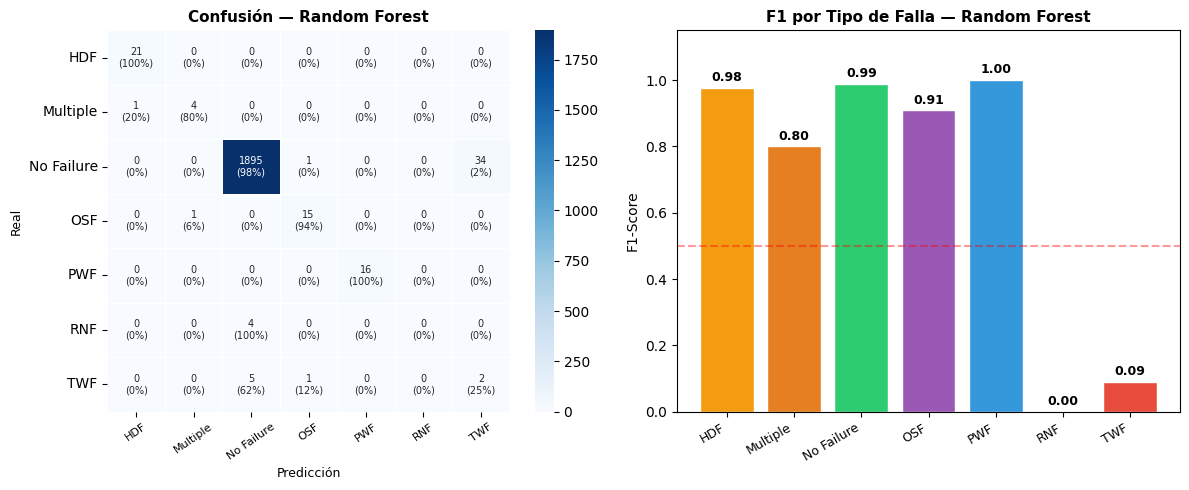

In [ ]:
# Matriz de confusión + F1 por clase del mejor modelo (Random Forest)
mejor = 'Random Forest'
y_pred_best = preds[mejor]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test_arr, y_pred_best)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
annot = np.array([[f'{v}\n({p:.0f}%)' for v, p in zip(row_v, row_p)]
                  for row_v, row_p in zip(cm, cm_pct)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=axes[0],
            xticklabels=clases, yticklabels=clases,
            linewidths=0.5, annot_kws={'size': 7})
axes[0].set_title(f'Confusión — {mejor}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicción', fontsize=9)
axes[0].set_ylabel('Real', fontsize=9)
axes[0].tick_params(axis='x', rotation=35, labelsize=8)

report = classification_report(y_test_arr, y_pred_best,
                               target_names=clases, output_dict=True, zero_division=0)
f1_vals = [report[c]['f1-score'] for c in clases]
tipo_colores = ['#f39c12', '#e67e22', '#2ecc71', '#9b59b6', '#3498db', '#1abc9c', '#e74c3c']
bars = axes[1].bar(range(len(clases)), f1_vals, color=tipo_colores, edgecolor='white')
for bar, val in zip(bars, f1_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(range(len(clases)))
axes[1].set_xticklabels(clases, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('F1-Score', fontsize=10)
axes[1].set_title(f'F1 por Tipo de Falla — {mejor}', fontsize=11, fontweight='bold')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
axes[1].set_ylim(0, 1.15)

plt.tight_layout()
plt.show()


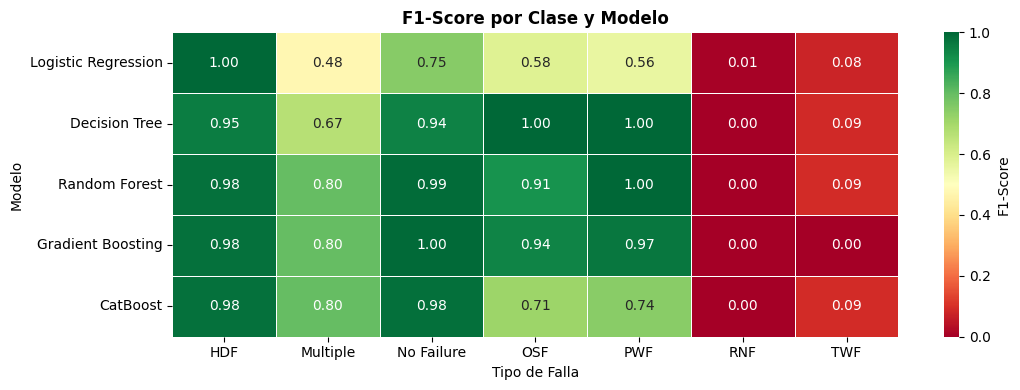

In [ ]:
# Heatmap: F1 por clase y modelo
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(f1_df, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            cbar_kws={'label': 'F1-Score'}, vmin=0, vmax=1, linewidths=0.5)
ax.set_title('F1-Score por Clase y Modelo', fontsize=12, fontweight='bold')
ax.set_xlabel('Tipo de Falla', fontsize=10)
ax.set_ylabel('Modelo', fontsize=10)
plt.tight_layout()
plt.show()


### Insights — Fase 4

**Tabla comparativa de los 5 modelos:**

| Modelo | AUC OvR | F1-macro | Recall macro | Precision macro |
|--------|---------|----------|--------------|-----------------|
| **Random Forest** | 0.914 | **0.681** | 0.710 | 0.670 |
| Gradient Boosting | 0.911 | 0.669 | 0.677 | 0.663 |
| Decision Tree | 0.858 | 0.665 | 0.732 | 0.672 |
| **CatBoost** | **0.926** | 0.615 | 0.717 | 0.564 |
| Logistic Regression | 0.939 | 0.493 | 0.827 | 0.455 |

**Hallazgos clave:**
- **Random Forest gana en F1-macro (0.681)**, métrica que pondera por igual todas las clases
- **CatBoost lidera en AUC One-vs-Rest (0.926)**, mejor que RF — ordena bien las probabilidades pero es más conservador
- Logistic Regression tiene el mejor AUC OvR pero el peor F1 — predice muchas cosas como falla, sube recall pero genera muchos falsos positivos
- **3 clases bien resueltas en casi todos los modelos:** PWF, HDF, OSF (F1 entre 0.94 y 1.00)
- **2 clases imposibles para todos los modelos:** TWF (F1 < 0.10) y RNF (F1 = 0)

**CatBoost vs Random Forest curioso:** CatBoost tiene mejor AUC pero peor F1 en PWF (0.74 vs 1.00) y OSF (0.71 vs 0.91). CatBoost distribuye más sus predicciones entre clases mientras que RF es más decidido.


---
## Fase 5 — Evaluación y Refinamiento

Feature Importance — Random Forest:
               Variable  Importancia  Acumulado
            wear_torque     0.145849  14.584884
          power_anomaly     0.107486  25.333523
                  power     0.101431  35.476584
        Tool wear [min]     0.096620  45.138562
     overheat_indicator     0.096248  54.763401
              temp_diff     0.070794  61.842808
            Torque [Nm]     0.062032  68.045999
     torque_speed_ratio     0.056948  73.740765
             wear_speed     0.055027  79.243441
 Rotational speed [rpm]     0.051585  84.401900
              high_wear     0.040417  88.443628
    Air temperature [K]     0.036788  92.122446
   overstrain_indicator     0.033582  95.480646
Process temperature [K]     0.027339  98.214567
                   Type     0.011375  99.352082
          extreme_speed     0.006479 100.000000

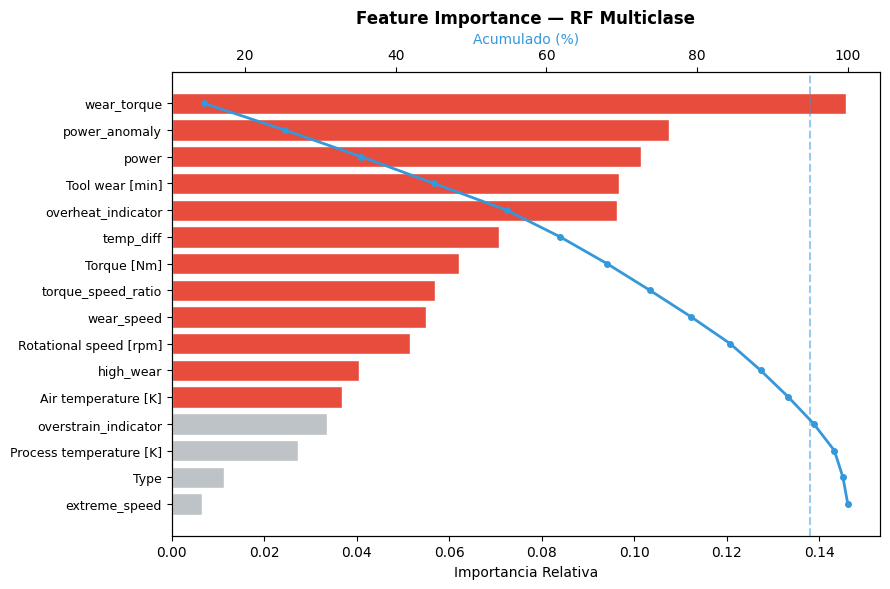

In [ ]:
# Feature Importance — Random Forest (mejor F1-macro)
rf = modelos['Random Forest']
importancias = rf.feature_importances_
df_imp = pd.DataFrame({
    'Variable': FEATURES,
    'Importancia': importancias / importancias.sum()
}).sort_values('Importancia', ascending=False).reset_index(drop=True)
df_imp['Acumulado'] = df_imp['Importancia'].cumsum() * 100

print("Feature Importance — Random Forest:")
print(df_imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if a <= 95 else '#bdc3c7' for a in df_imp['Acumulado']]
ax.barh(range(len(df_imp)), df_imp['Importancia'], color=colors, edgecolor='white')
ax.set_yticks(range(len(df_imp)))
ax.set_yticklabels(df_imp['Variable'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Importancia Relativa', fontsize=10)
ax.set_title('Feature Importance — Random Forest Multiclase', fontsize=12, fontweight='bold')

ax2 = ax.twiny()
ax2.plot(df_imp['Acumulado'].values, range(len(df_imp)),
         'o-', color='#3498db', linewidth=2, markersize=4)
ax2.axvline(x=95, color='#3498db', linestyle='--', alpha=0.5)
ax2.set_xlabel('Acumulado (%)', fontsize=10, color='#3498db')

plt.tight_layout()
plt.show()


### Insights — Fase 5
- Top: wear_torque (~14%), power_anomaly (~11%), power (~10%), Tool wear (~10%)
- Los indicadores binarios son altamente discriminativos para HDF, PWF y OSF
- **Recomendación:** Pipeline jerárquico: detección (binario) → clasificación (HDF/PWF/OSF)
- TWF y RNF requieren estrategia complementaria (más datos, otras señales o redundancia operativa)


---
## Fase 6 — Despliegue

**Modelo seleccionado:** Random Forest (n_estimators=150, max_depth=12, class_weight='balanced')

**Comparación final de los 5 modelos:**

| Modelo | AUC OvR | F1-macro | Mejor en |
|--------|---------|----------|----------|
| Random Forest | 0.914 | **0.681** | F1-macro general |
| Gradient Boosting | 0.911 | 0.669 | Balance |
| Decision Tree | 0.858 | 0.665 | Interpretabilidad |
| CatBoost | **0.926** | 0.615 | AUC OvR (probabilidades) |
| Logistic Regression | 0.939 | 0.493 | Recall macro (0.83) |

**F1 por clase del modelo final (Random Forest):**

| Clase | F1 | Estado |
|-------|-----|--------|
| PWF | 1.00 | ✅ Perfecto |
| HDF | 0.98 | ✅ Excelente |
| OSF | 0.91 | ✅ Muy bueno |
| No Failure | 0.99 | ✅ Excelente |
| Multiple | 0.80 | ✅ Bueno |
| TWF | 0.09 | ❌ Problemático |
| RNF | 0.00 | ❌ Impredecible |

**Recomendaciones:**
1. **Excluir RNF del scope del modelo** — no es predecible, gestionar con MTBF y stock de repuestos
2. **Considerar fusionar TWF + OSF** en una categoría "desgaste mecánico"
3. **Pipeline jerárquico** detección → clasificación
4. **CatBoost como modelo complementario** para zonas de incertidumbre dado su mejor AUC OvR
5. **Monitorear drift** en distribuciones de torque, RPM y desgaste


In [ ]:
import pickle, json

# Guardar Random Forest (mejor F1-macro)
with open('mc_modelo_rf.pkl', 'wb') as f:
    pickle.dump(modelos['Random Forest'], f)

# Guardar CatBoost (mejor AUC OvR — modelo complementario)
with open('mc_modelo_catboost.pkl', 'wb') as f:
    pickle.dump(modelos['CatBoost'], f)

metadata = {
    'modelo_principal': 'Random Forest',
    'modelo_complementario': 'CatBoost',
    'features': FEATURES,
    'target': 'failure_type',
    'clases': clases,
    'metricas_rf': {'AUC_OvR': 0.914, 'F1_macro': 0.681, 'Recall_macro': 0.710},
    'metricas_catboost': {'AUC_OvR': 0.926, 'F1_macro': 0.615, 'Recall_macro': 0.717},
    'clases_excelentes': ['PWF', 'HDF', 'OSF', 'No Failure'],
    'clases_problematicas': ['TWF', 'RNF']
}
with open('mc_modelo_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Modelos guardados: Random Forest + CatBoost")
print(f"Clases: {clases}")


Modelos guardados: Random Forest + CatBoost
Clases: ['HDF', 'Multiple', 'No Failure', 'OSF', 'PWF', 'RNF', 'TWF']
